<a href="https://colab.research.google.com/github/ibarr123/BUS1182026/blob/main/Agentic_AI_in_Supply_Chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Auto-generated files created:
- sales.csv
- inventory.csv
- params.csv

Sales sample:


,date,sku,qty_sold
0,2024-01-01,SKU_A,23
1,2024-01-02,SKU_A,27
2,2024-01-03,SKU_A,23
3,2024-01-04,SKU_A,25
4,2024-01-05,SKU_A,20


Inventory:


,sku,opening_stock
0,SKU_A,180
1,SKU_B,120
2,SKU_C,100


Params:


...

,policy,sku,stockouts_units,fill_rate,holding_cost,stockout_cost,order_cost,total_cost
0,agent,SKU_A,0.0,1.000000,480.32,0.0,825.0,1305.32
1,agent,SKU_B,0.0,1.000000,474.20,0.0,765.0,1239.20
2,agent,SKU_C,3.0,0.996982,175.90,9.0,585.0,769.90


Overall comparison:


,policy,sku,stockouts_units,fill_rate,holding_cost,stockout_cost,order_cost,total_cost
0,baseline,ALL,6.0,0.998327,1357.84,27.0,735.0,2119.84
1,agent,ALL,3.0,0.998994,1130.42,9.0,2175.0,3314.42



Sample daily agent log:


,date,sku,policy,demand_today,arriving,on_hand_end,backlog_end,pipeline_total,inventory_position,forecast_next_day,forecast_error_std,safety_stock,reorder_point,order_qty,rationale
0,2024-01-01,SKU_A,agent,23.0,0.0,157.0,0.0,0.0,157.0,0.000000,0.000000,0.000000,0.000000,0,Agent waited because inventory_position (157.0...
1,2024-01-01,SKU_B,agent,14.0,0.0,106.0,0.0,0.0,106.0,0.000000,0.000000,0.000000,0.000000,0,Agent waited because inventory_position (106.0...
2,2024-01-01,SKU_C,agent,10.0,0.0,90.0,0.0,0.0,90.0,0.000000,0.000000,0.000000,0.000000,0,Agent waited because inventory_position (90.0)...
3,2024-01-02,SKU_A,agent,27.0,0.0,130.0,0.0,40.0,130.0,23.000000,0.000000,0.000000,138.000000,40,Agent ordered because inventory_position (130....
4,2024-01-02,SKU_B,agent,18.0,0.0,88.0,0.0,30.0,88.0,14.000000,0.000000,0.000000,112.000000,30,Agent ordered because inventory_position (88.0...
5,2024-01-02,SKU_C,agent,12.0,0.0,78.0,0.0,0.0,78.0,10.000000,0.000000,0.000000,50.000000,0,Agent waited because inventory_position (78.0)...
6,2024-01-03,SKU_A,agent,23.0,0.0,107.0,0.0,40.0,147.0,24.400000,0.000000,0.000000,146.400000,0,Agent waited because inventory_position (147.0...
7,2024-01-03,SKU_B,agent,18.0,0.0,70.0,0.0,60.0,100.0,15.400000,0.000000,0.000000,123.200000,30,Agent ordered because inventory_position (100....
8,2024-01-03,SKU_C,agent,12.0,0.0,66.0,0.0,0.0,66.0,10.700000,0.000000,0.000000,53.500000,0,Agent waited because inventory_position (66.0)...
9,2024-01-04,SKU_A,agent,25.0,0.0,82.0,0.0,80.0,122.0,23.910000,3.818377,15.384438,158.844438,40,Agent ordered because inventory_position (122....


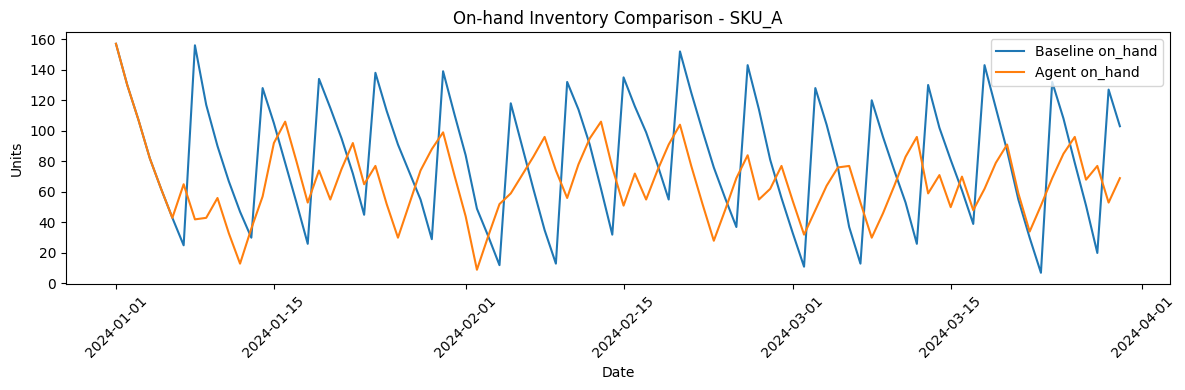

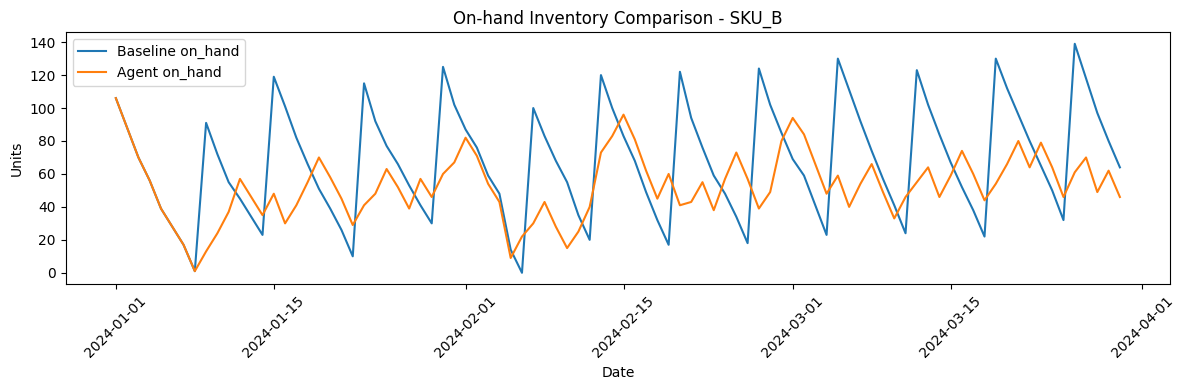

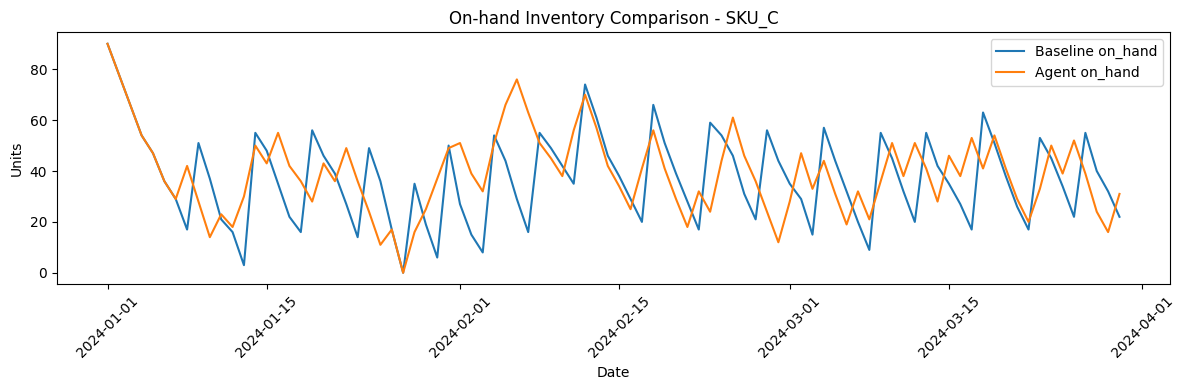

Trade-off Reflection:
The baseline policy had total cost = 2119.84 and fill rate = 0.998. The agent policy had total cost = 3314.42 and fill rate = 0.999. This shows the inventory-service trade-off: ordering more aggressively can reduce stockouts and improve customer service, but it may increase holding cost. Ordering too conservatively reduces holding cost but can increase stockouts, hurting fill rate and customer trust.


In [ ]:
# =================================
# Inventory Replenishment Agent
# =================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import norm

# ----------------------------
# 1. Auto-generate CSV files
# ----------------------------

rng = np.random.default_rng(42)

def generate_data_files(num_days=90):
    dates = pd.date_range("2024-01-01", periods=num_days, freq="D")
    skus = ["SKU_A", "SKU_B", "SKU_C"]

    # Generate sales.csv
    sales_rows = []
    for sku in skus:
        if sku == "SKU_A":
            base = 22
            weekly_amp = 5
            trend = np.linspace(0, 4, num_days)
        elif sku == "SKU_B":
            base = 15
            weekly_amp = 3
            trend = np.linspace(0, 2, num_days)
        else:
            base = 10
            weekly_amp = 2
            trend = np.linspace(0, 1, num_days)

        for i, date in enumerate(dates):
            dow = date.dayofweek
            weekly = weekly_amp * np.sin(2 * np.pi * dow / 7)
            noise = rng.normal(0, 2)
            promo = rng.integers(6, 14) if rng.random() < 0.08 else 0
            qty_sold = max(0, round(base + weekly + trend[i] + promo + noise))
            sales_rows.append([date, sku, qty_sold])

    sales = pd.DataFrame(sales_rows, columns=["date", "sku", "qty_sold"])

    # inventory.csv
    inventory = pd.DataFrame({
        "sku": skus,
        "opening_stock": [180, 120, 100]
    })

    # params.csv
    params = pd.DataFrame({
        "sku": skus,
        "unit_cost": [8.0, 12.0, 5.0],
        "holding_cost_per_day": [0.08, 0.10, 0.05],
        "stockout_cost": [4.0, 6.0, 3.0],
        "lead_time_days": [5, 7, 4],
        "min_order_qty": [40, 30, 25],
        "service_level": [0.95, 0.97, 0.93]
    })

    sales.to_csv("sales.csv", index=False)
    inventory.to_csv("inventory.csv", index=False)
    params.to_csv("params.csv", index=False)

    return sales, inventory, params

sales_gen, inventory_gen, params_gen = generate_data_files(num_days=90)

print("Auto-generated files created:")
print("- sales.csv")
print("- inventory.csv")
print("- params.csv")

# ----------------------------
# 2. Load CSV files
# ----------------------------

sales = pd.read_csv("sales.csv", parse_dates=["date"])
inventory = pd.read_csv("inventory.csv")
params = pd.read_csv("params.csv")

print("\nSales sample:")
display(sales.head())

print("Inventory:")
display(inventory)

print("Params:")
display(params)

# ----------------------------
# 3. Aggregate demand per day per SKU
# ----------------------------

daily_sales = (
    sales.groupby(["date", "sku"], as_index=False)["qty_sold"]
    .sum()
    .sort_values(["sku", "date"])
)

print("Aggregated daily sales:")
display(daily_sales.head(10))

# ----------------------------
# 4. Forecast helpers (EWMA)
# ----------------------------

ALPHA = 0.35
REVIEW_PERIOD_DAYS = 1
ORDER_COST_PER_PO = 15.0   # fixed ordering cost
INVENTORY_CAP_MULTIPLIER = 3.0  # guardrail to reduce unrealistic over-ordering

def ewma_forecast(history, alpha=0.35):
    """
    Returns next-day EWMA forecast using only historical actual demand.
    """
    history = list(history)
    if len(history) == 0:
        return 0.0
    forecast = history[0]
    for actual in history[1:]:
        forecast = alpha * actual + (1 - alpha) * forecast
    return max(0.0, forecast)

def rolling_forecast_errors(history, alpha=0.35):
    """
    One-step-ahead rolling forecast errors for safety stock estimation.
    """
    history = list(history)
    if len(history) < 3:
        return [0.0]

    errors = []
    for i in range(1, len(history)):
        pred = ewma_forecast(history[:i], alpha)
        errors.append(history[i] - pred)
    return errors if errors else [0.0]

def z_value(service_level):
    return norm.ppf(service_level)

# ----------------------------
# 5. Baseline policy
# ----------------------------

def baseline_decision(on_hand, pipeline_qty, backlog, history, sku_params):
    """
    Simple baseline: static reorder point based on average historical demand.
    No dynamic safety stock update from forecast error.
    """
    lead_time = int(sku_params["lead_time_days"])
    min_order_qty = int(sku_params["min_order_qty"])
    service_level = float(sku_params["service_level"])

    avg_demand = np.mean(history) if len(history) > 0 else 0.0
    demand_std = np.std(history, ddof=1) if len(history) > 1 else 0.0

    reorder_point = (
        avg_demand * lead_time
        + z_value(service_level) * demand_std * np.sqrt(lead_time)
    )

    inventory_position = on_hand + pipeline_qty - backlog

    # Simple order-up-to logic
    order_up_to = reorder_point + (avg_demand * lead_time)

    if inventory_position <= reorder_point:
        raw_qty = max(0, order_up_to - inventory_position)
        order_qty = max(min_order_qty, int(np.ceil(raw_qty)))
        rationale = (
            f"Baseline ordered because inventory_position ({inventory_position:.1f}) "
            f"<= reorder_point ({reorder_point:.1f})."
        )
    else:
        order_qty = 0
        rationale = (
            f"Baseline waited because inventory_position ({inventory_position:.1f}) "
            f"> reorder_point ({reorder_point:.1f})."
        )

    return order_qty, rationale

# ----------------------------
# 6. Agent policy
# ----------------------------

def agent_decision(on_hand, pipeline_qty, backlog, history, sku_params, alpha=0.35, review_period=1):
    """
    Dynamic agent:
    - EWMA forecast
    - Safety stock from forecast error and service level
    - Projects demand over lead time + review period
    - Respects min_order_qty
    - Adds inventory cap guardrail
    """
    lead_time = int(sku_params["lead_time_days"])
    min_order_qty = int(sku_params["min_order_qty"])
    service_level = float(sku_params["service_level"])

    forecast_next_day = ewma_forecast(history, alpha)
    errors = rolling_forecast_errors(history, alpha)
    error_std = np.std(errors, ddof=1) if len(errors) > 1 else 0.0

    protection_period = lead_time + review_period

    expected_demand_during_protection = forecast_next_day * protection_period
    safety_stock = z_value(service_level) * error_std * np.sqrt(protection_period)
    reorder_point = expected_demand_during_protection + safety_stock

    inventory_position = on_hand + pipeline_qty - backlog

    # Order-up-to level
    order_up_to = expected_demand_during_protection + safety_stock

    # Guardrail to prevent unrealistic over-ordering
    max_inventory_cap = expected_demand_during_protection * INVENTORY_CAP_MULTIPLIER + safety_stock

    if inventory_position <= reorder_point:
        raw_qty = max(0, order_up_to - inventory_position)
        order_qty = max(min_order_qty, int(np.ceil(raw_qty)))

        # cap order if it would create excessive inventory
        projected_post_order_position = inventory_position + order_qty
        if projected_post_order_position > max_inventory_cap:
            capped_qty = max(0, int(np.ceil(max_inventory_cap - inventory_position)))
            if capped_qty > 0:
                order_qty = max(min_order_qty, capped_qty)
            else:
                order_qty = 0

        rationale = (
            f"Agent ordered because inventory_position ({inventory_position:.1f}) <= "
            f"reorder_point ({reorder_point:.1f}); forecast={forecast_next_day:.2f}, "
            f"safety_stock={safety_stock:.2f}, lead_time={lead_time}, "
            f"service_level={service_level:.2f}."
        )
    else:
        order_qty = 0
        rationale = (
            f"Agent waited because inventory_position ({inventory_position:.1f}) > "
            f"reorder_point ({reorder_point:.1f}); forecast={forecast_next_day:.2f}, "
            f"safety_stock={safety_stock:.2f}."
        )

    return {
        "order_qty": int(order_qty),
        "forecast_next_day": float(forecast_next_day),
        "error_std": float(error_std),
        "safety_stock": float(safety_stock),
        "reorder_point": float(reorder_point),
        "inventory_position": float(inventory_position),
        "rationale": rationale
    }

# ----------------------------
# 7. Simulation engine
# ----------------------------

def run_simulation(daily_sales, inventory, params, policy_name="agent", alpha=0.35, review_period=1, verbose=True):
    """
    Simulates inventory day by day for all SKUs.
    Tracks:
    - stockouts
    - fill rate
    - holding cost
    - stockout cost
    - order cost
    - total cost
    - daily logs
    """
    skus = sorted(daily_sales["sku"].unique())
    all_dates = sorted(daily_sales["date"].unique())

    inventory_map = inventory.set_index("sku")["opening_stock"].to_dict()
    params_map = params.set_index("sku").to_dict(orient="index")

    demand_lookup = daily_sales.set_index(["date", "sku"])["qty_sold"].to_dict()

    state = {}
    for sku in skus:
        lead_time = int(params_map[sku]["lead_time_days"])
        state[sku] = {
            "on_hand": float(inventory_map[sku]),
            "backlog": 0.0,
            "pipeline": [0.0] * lead_time,
            "history": [],
            "holding_cost": 0.0,
            "stockout_cost": 0.0,
            "order_cost": 0.0,
            "units_demanded": 0.0,
            "units_fulfilled": 0.0,
            "units_stockout": 0.0
        }

    daily_logs = []

    for current_date in all_dates:
        for sku in skus:
            sku_params = params_map[sku]
            lead_time = int(sku_params["lead_time_days"])
            holding_cost_per_day = float(sku_params["holding_cost_per_day"])
            stockout_cost = float(sku_params["stockout_cost"])

            # Receive arriving PO
            arriving = state[sku]["pipeline"].pop(0)
            state[sku]["on_hand"] += arriving
            state[sku]["pipeline"].append(0.0)

            demand_today = float(demand_lookup.get((current_date, sku), 0.0))
            state[sku]["units_demanded"] += demand_today

            total_need = demand_today + state[sku]["backlog"]
            shipped = min(state[sku]["on_hand"], total_need)
            state[sku]["on_hand"] -= shipped

            previous_backlog = state[sku]["backlog"]
            state[sku]["backlog"] = total_need - shipped

            new_stockout_units = max(0.0, state[sku]["backlog"] - previous_backlog)
            state[sku]["units_stockout"] += new_stockout_units
            state[sku]["units_fulfilled"] += min(demand_today, shipped)

            # Decision
            pipeline_qty = sum(state[sku]["pipeline"])
            history = state[sku]["history"]

            if policy_name == "baseline":
                order_qty, rationale = baseline_decision(
                    on_hand=state[sku]["on_hand"],
                    pipeline_qty=pipeline_qty,
                    backlog=state[sku]["backlog"],
                    history=history,
                    sku_params=sku_params
                )
                forecast_next_day = np.mean(history) if len(history) > 0 else 0.0
                error_std = np.std(history, ddof=1) if len(history) > 1 else 0.0
                safety_stock = 0.0
                reorder_point = 0.0
                inventory_position = state[sku]["on_hand"] + pipeline_qty - state[sku]["backlog"]

            else:
                decision = agent_decision(
                    on_hand=state[sku]["on_hand"],
                    pipeline_qty=pipeline_qty,
                    backlog=state[sku]["backlog"],
                    history=history,
                    sku_params=sku_params,
                    alpha=alpha,
                    review_period=review_period
                )
                order_qty = decision["order_qty"]
                forecast_next_day = decision["forecast_next_day"]
                error_std = decision["error_std"]
                safety_stock = decision["safety_stock"]
                reorder_point = decision["reorder_point"]
                inventory_position = decision["inventory_position"]
                rationale = decision["rationale"]

            # Place PO
            if order_qty > 0:
                state[sku]["pipeline"][-1] += order_qty
                state[sku]["order_cost"] += ORDER_COST_PER_PO

            # Daily costs
            state[sku]["holding_cost"] += state[sku]["on_hand"] * holding_cost_per_day
            state[sku]["stockout_cost"] += state[sku]["backlog"] * stockout_cost

            # Save demand history AFTER observing actual today
            state[sku]["history"].append(demand_today)

            log_row = {
                "date": current_date,
                "sku": sku,
                "policy": policy_name,
                "demand_today": demand_today,
                "arriving": arriving,
                "on_hand_end": state[sku]["on_hand"],
                "backlog_end": state[sku]["backlog"],
                "pipeline_total": sum(state[sku]["pipeline"]),
                "inventory_position": inventory_position,
                "forecast_next_day": forecast_next_day,
                "forecast_error_std": error_std,
                "safety_stock": safety_stock,
                "reorder_point": reorder_point,
                "order_qty": order_qty,
                "rationale": rationale
            }
            daily_logs.append(log_row)

            if verbose:
                print(
                    f"[{current_date.date()}] {policy_name.upper()} | {sku} | "
                    f"demand={demand_today:.0f}, arrive={arriving:.0f}, "
                    f"on_hand={state[sku]['on_hand']:.0f}, backlog={state[sku]['backlog']:.0f}, "
                    f"pipeline={sum(state[sku]['pipeline']):.0f}, order={order_qty} | "
                    f"{rationale}"
                )

    # KPI summary
    summary_rows = []
    for sku in skus:
        units_demanded = state[sku]["units_demanded"]
        units_fulfilled = state[sku]["units_fulfilled"]
        fill_rate = units_fulfilled / units_demanded if units_demanded > 0 else 1.0
        total_cost = (
            state[sku]["holding_cost"]
            + state[sku]["stockout_cost"]
            + state[sku]["order_cost"]
        )

        summary_rows.append({
            "policy": policy_name,
            "sku": sku,
            "stockouts_units": state[sku]["units_stockout"],
            "fill_rate": fill_rate,
            "holding_cost": state[sku]["holding_cost"],
            "stockout_cost": state[sku]["stockout_cost"],
            "order_cost": state[sku]["order_cost"],
            "total_cost": total_cost
        })

    summary = pd.DataFrame(summary_rows)
    logs = pd.DataFrame(daily_logs)

    overall = pd.DataFrame([{
        "policy": policy_name,
        "sku": "ALL",
        "stockouts_units": summary["stockouts_units"].sum(),
        "fill_rate": summary["fill_rate"].mean(),
        "holding_cost": summary["holding_cost"].sum(),
        "stockout_cost": summary["stockout_cost"].sum(),
        "order_cost": summary["order_cost"].sum(),
        "total_cost": summary["total_cost"].sum()
    }])

    return summary, overall, logs

# ----------------------------
# 8. Run both policies
# ----------------------------

print("\n--- RUNNING BASELINE ---")
baseline_summary, baseline_overall, baseline_logs = run_simulation(
    daily_sales, inventory, params,
    policy_name="baseline",
    alpha=ALPHA,
    review_period=REVIEW_PERIOD_DAYS,
    verbose=False
)

print("\n--- RUNNING AGENT ---")
agent_summary, agent_overall, agent_logs = run_simulation(
    daily_sales, inventory, params,
    policy_name="agent",
    alpha=ALPHA,
    review_period=REVIEW_PERIOD_DAYS,
    verbose=False
)

print("\nBaseline summary:")
display(baseline_summary)

print("Agent summary:")
display(agent_summary)

print("Overall comparison:")
comparison = pd.concat([baseline_overall, agent_overall], ignore_index=True)
display(comparison)

# ----------------------------
# 9. Show daily agent log
# ----------------------------

print("\nSample daily agent log:")
display(agent_logs.head(20))

# ----------------------------
# 10. Visualization
# ----------------------------

agent_all = agent_logs.copy()
baseline_all = baseline_logs.copy()

for sku in sorted(daily_sales["sku"].unique()):
    plt.figure(figsize=(12, 4))
    b = baseline_all[baseline_all["sku"] == sku]
    a = agent_all[agent_all["sku"] == sku]

    plt.plot(b["date"], b["on_hand_end"], label="Baseline on_hand")
    plt.plot(a["date"], a["on_hand_end"], label="Agent on_hand")
    plt.title(f"On-hand Inventory Comparison - {sku}")
    plt.xlabel("Date")
    plt.ylabel("Units")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ----------------------------
# 11. Simple reflection text
# ----------------------------

baseline_total_cost = float(baseline_overall["total_cost"].iloc[0])
agent_total_cost = float(agent_overall["total_cost"].iloc[0])
baseline_fill_rate = float(baseline_overall["fill_rate"].iloc[0])
agent_fill_rate = float(agent_overall["fill_rate"].iloc[0])

print("Trade-off Reflection:")
print(
    f"The baseline policy had total cost = {baseline_total_cost:.2f} and fill rate = {baseline_fill_rate:.3f}. "
    f"The agent policy had total cost = {agent_total_cost:.2f} and fill rate = {agent_fill_rate:.3f}. "
    f"This shows the inventory-service trade-off: ordering more aggressively can reduce stockouts and improve "
    f"customer service, but it may increase holding cost. Ordering too conservatively reduces holding cost but "
    f"can increase stockouts, hurting fill rate and customer trust."
)